In [130]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import seaborn as sns
import pandas as pd 

%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")


In [140]:
# # Load mean sea surface temperature dataset
# ds_ref = xr.open_dataset("../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")

# ds = xr.open_dataset("../data/sst.wkmean.1990-present.nc", engine="netcdf4") # 1727 but no countries

# higher resolution
ds = xr.open_dataset("../data/sst.week.mean.nc", engine="netcdf4") 

# xarray's HTML representation
ds_copy = ds.copy(deep=True)

/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_13191/2759436001.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset("../sst.day.mean.ltm.1991-2020.nc", engine="netcdf4")
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_13191/2759436001.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset("../sst.day.mean.ltm.1991-2020.nc", engine="netcdf4")


In [141]:
ds['sst'].shape

(365, 720, 1440)

In [139]:
ds['sst'].time[:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['1981-09-06T00:00:00.000000000', '1981-09-13T00:00:00.000000000',
       '1981-09-20T00:00:00.000000000', '1981-09-27T00:00:00.000000000',
       '1981-10-04T00:00:00.000000000', '1981-10-11T00:00:00.000000000',
       '1981-10-18T00:00:00.000000000', '1981-10-25T00:00:00.000000000',
       '1981-11-01T00:00:00.000000000', '1981-11-08T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 80B 1981-09-06 1981-09-13 ... 1981-11-08
Attributes:
    long_name:     Time
    delta_t:       0000-00-07 00:00:00
    avg_period:    0000-00-07 00:00:00
    axis:          T
    actual_range:  [66357. 82625.]

In [4]:
indices = np.argwhere(np.isnan(ds_ref.sst[0].data))
for (idx_y, idx_x) in indices:
    ds.sst[dict(lat=-idx_y, lon=idx_x)] = np.nan

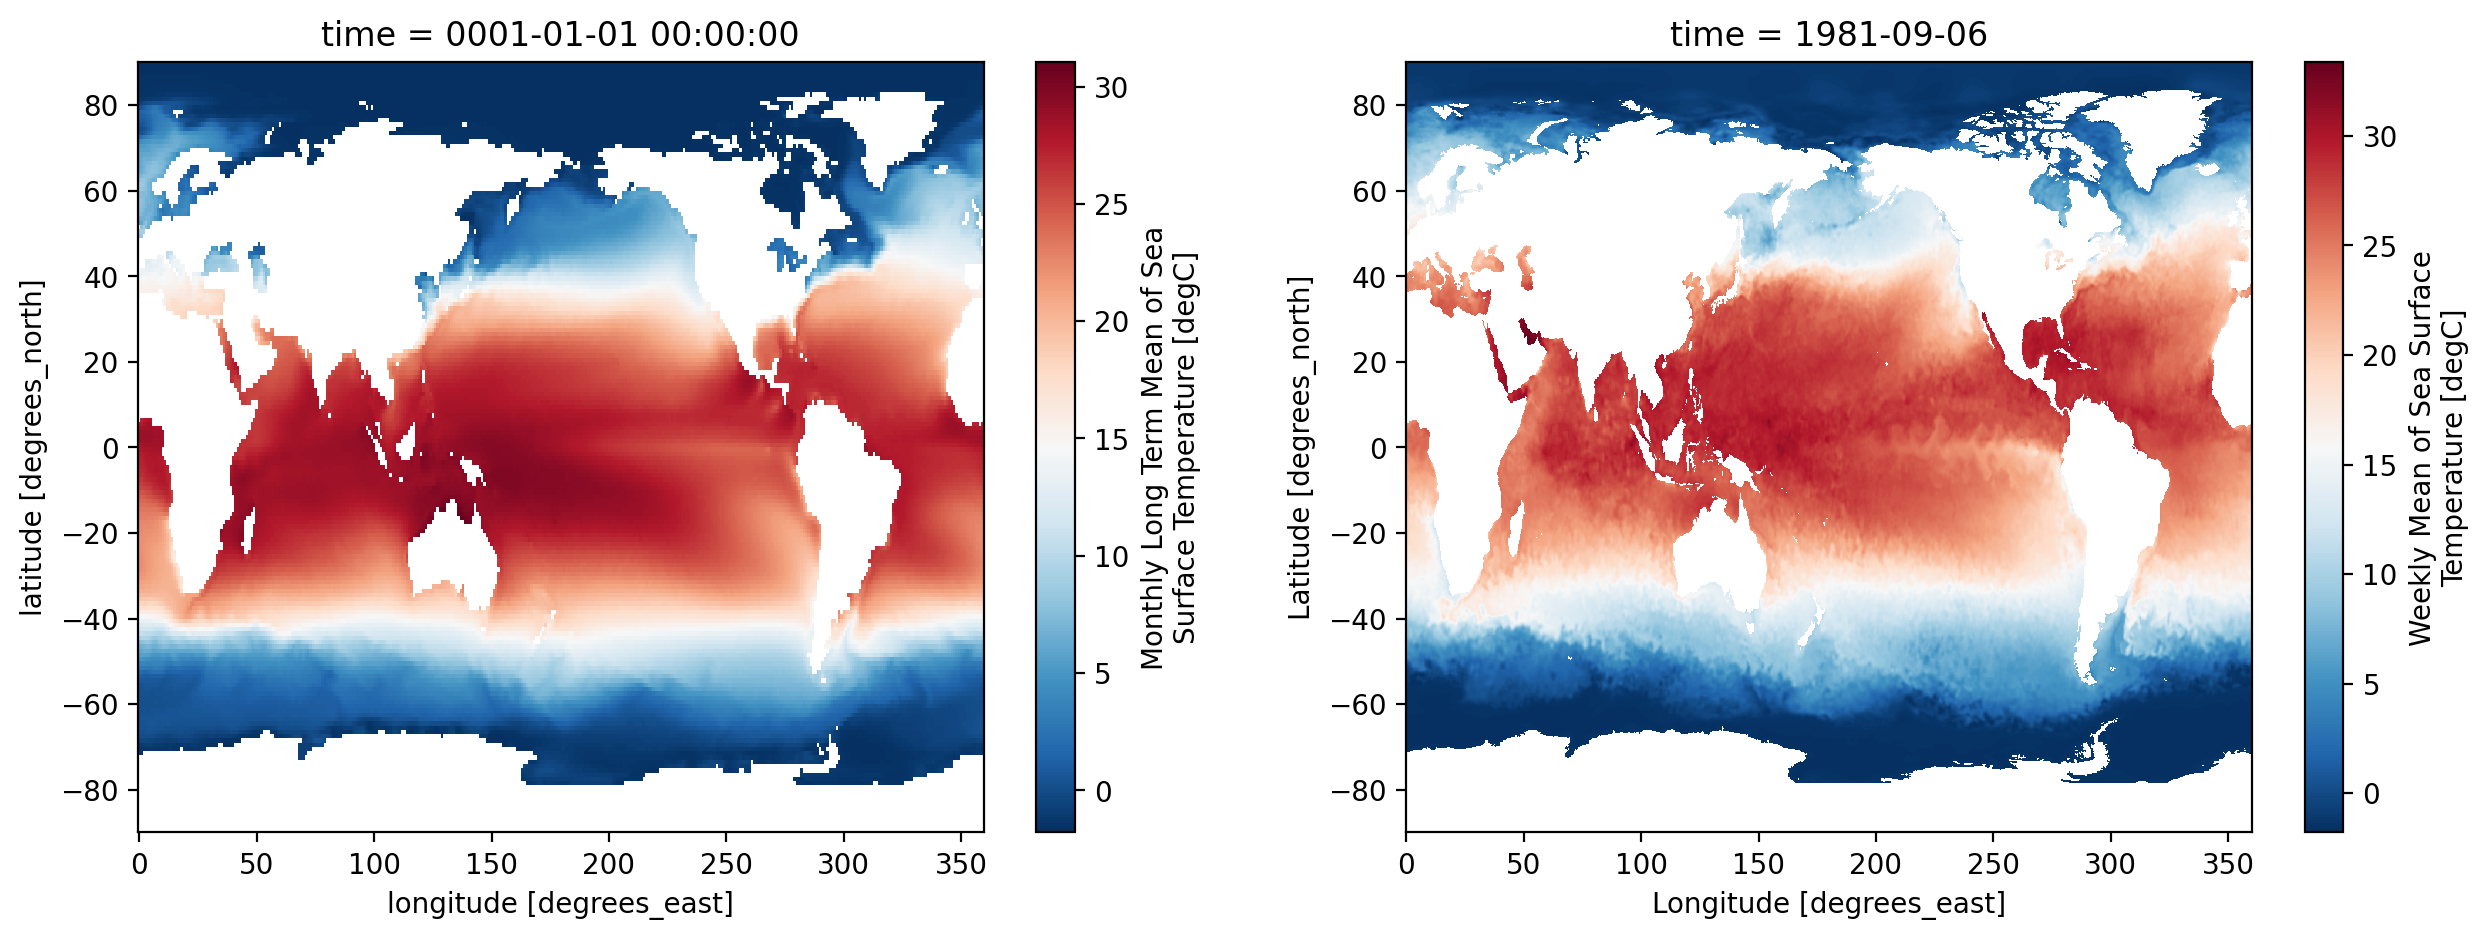

In [134]:
plt.figure(figsize=(15,5))
plt.subplot(121)
ds_ref.sst[0].plot(center=False, cmap='RdBu_r')
plt.subplot(122)
ds.sst[0].plot(center=False, cmap='RdBu_r')

In [6]:
import hvplot
import hvplot.xarray


In [7]:
min_temp, max_temp = ds.sst.attrs['actual_range']

In [8]:
min_temp, max_temp

(np.float32(-1.8), np.float32(36.16))

In [110]:
timeseries_slider = ds['sst'].hvplot(
        x="lon",
        y="lat",
        cmap="coolwarm",
        groupby="time",
        clim=(min_temp, max_temp),
        xlabel="Longitude (degrees_east)",
        ylabel="Latitude (degrees_north)",
        # title="Raw SST (weekly mean) with time slider",
        widget_location="bottom",
        widget_type='scrubber',
    )


In [111]:
type(timeseries_slider[1][0])

panel.widgets.player.Player

In [112]:
timeseries_slider

BokehModel(combine_events=True, render_bundle={'docs_json': {'7ef26004-807b-4ba1-8924-0f05a1e33f65': {'version…

In [115]:
import panel 

In [ ]:
from bokeh.plotting import figure

p1 = figure(width=300, height=300, name='Scatter')
p1.scatter([0, 1, 2, 3, 4, 5, 6], [0, 1, 2, 3, 2, 1, 0])

p2 = figure(width=300, height=300, name='Line')
p2.line([0, 1, 2, 3, 4, 5, 6], [0, 1, 2, 3, 2, 1, 0])

tabs = panel.Tabs(
                ('Scatter', p1),
                p2,
                tabs_location="left",
                sizing_mode="stretch_both",
                dynamic=True,
)
tabs